In [122]:
#!/usr/bin/env python
import tifffile
import pandas as pd
import numpy as np
from skimage.measure import regionprops_table
import warnings
import argparse 
from pathlib import Path
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [123]:
def rotate(mat, angle_deg, center=None, dims=(0, 1)):
    """
    Rotate points in the plane defined by dims by angle_deg degrees.

    Parameters
    ----------
    mat : (n, d) array
        Input coordinates, e.g. PCA coordinates.
    angle_deg : float
        Rotation angle in degrees. Positive = counterclockwise.
    center : array-like of shape (2,), optional
        Center of rotation in the selected dims.
        If None, uses the centroid in those dims.
    dims : tuple of int
        Which two columns to rotate. Default: (0, 1).

    Returns
    -------
    out : (n, d) array
        Rotated copy of mat.
    """
    mat = np.asarray(mat, dtype=float)
    out = mat.copy()

    Y = out[:, dims]

    if center is None:
        center = Y.mean(axis=0)
    else:
        center = np.asarray(center, dtype=float)

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])

    out[:, dims] = (Y - center) @ R.T + center
    return out


def standardize(mat, dims=(0, 1)):
    """
    Scale each selected axis independently to span [-1, 1].

    Parameters
    ----------
    mat : (n, d) array
    dims : tuple of int
        Which columns to rescale.

    Returns
    -------
    out : (n, d) array
    """
    mat = np.asarray(mat, dtype=float)
    out = mat.copy()

    for d in dims:
        x = out[:, d]
        xmin, xmax = x.min(), x.max()
        if np.isclose(xmax, xmin):
            out[:, d] = 0.0
        else:
            out[:, d] = 2 * (x - xmin) / (xmax - xmin) - 1

    return out

In [124]:
image_path = Path('batch1/mCherryi_3_0.24.tif')
mask_path = Path('batch1/mCherryi_3_0.24_cp_masks.tif')

In [125]:
if image_path.is_file():
    img = tifffile.imread(image_path)
    if img.ndim == 4:
        # Move channel axis to the end while preserving
        # the order of x and y axes
        img = np.swapaxes(img, 1, 2)
        img = np.swapaxes(img, 2, 3)
else:
    raise FileNotFoundError(f"{image_path} is not found")

In [126]:
logging.info(f"Image shape: {img.shape}")

if mask_path.is_file():
    roi = tifffile.imread(mask_path)
else:
    raise FileNotFoundError(f"{mask_path} is not found")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    props = regionprops_table(
        roi,
        img,
        properties=(
            'label', 'centroid', 'area_convex',
            'axis_major_length', 'equivalent_diameter_area', 'intensity_mean'
        ),
        separator='_',
    )

propsdf = pd.DataFrame(props)
outdf = pd.DataFrame({
    'label': propsdf['label'],
    'centroid_x': propsdf['centroid_0'],
    'centroid_y': propsdf['centroid_1'],
    'centroid_z': propsdf['centroid_2'],
    'area': propsdf['area_convex'],
    'aspherity': propsdf['axis_major_length'] / propsdf['equivalent_diameter_area'],
})

if img.ndim == 3:
    outdf['int'] = propsdf['intensity_mean']
else:
    for i in range(img.shape[3]):
        intensity_col = f'intensity_mean_{i}'
        if intensity_col not in propsdf:
            intensity_col = f'intensity_mean-{i}'
        outdf[f'int_{i}'] = propsdf[intensity_col]

2026-06-08 18:01:20,641 - INFO - Image shape: (170, 1024, 1024)


In [127]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

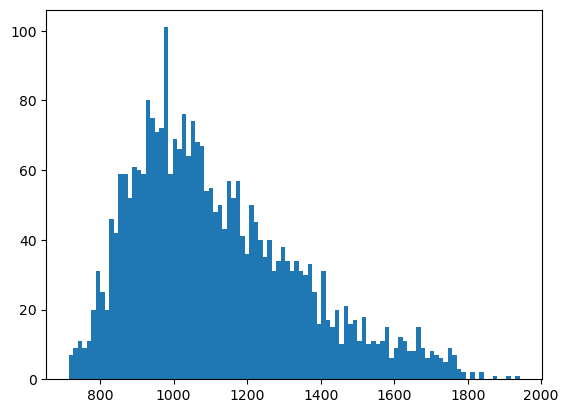

In [128]:
_ = plt.hist(outdf['int'], bins=100)

In [129]:
pca = PCA(n_components=3, svd_solver='auto')
pcaobj = pca.fit_transform(outdf[['centroid_x', 'centroid_y', 'centroid_z']].to_numpy())

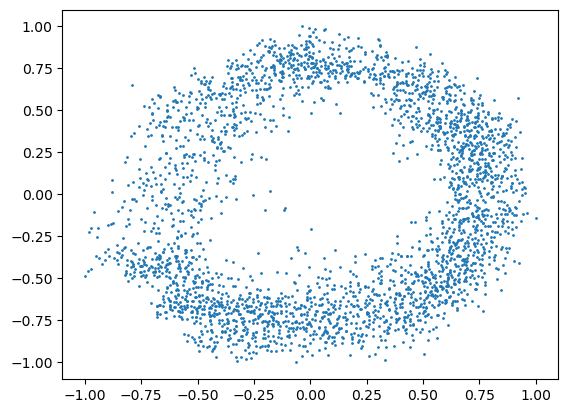

In [130]:
rot = 75
pcamat2 = standardize(rotate(pcaobj, rot))

_ = plt.scatter(pcamat2[:, 0], pcamat2[:, 1], s = 1)